# Virtual Motif Knockout Experiments

Perform virtual MYRF-1 motif knockout experiments on AlphaGenome FT ChIP-seq predictions.

**Approach:**
1. Select a 1000bp window centered on a top MYRF-1 motif hit
2. Find all MYRF-1 motifs within that window
3. Select which motif(s) to KO by index (left-to-right)
4. Dinucleotide-shuffle the full WT sequence N times
5. For each replicate: start from WT, replace KO'd motif positions with bases from the shuffled copy
6. Average predictions over N replicates to marginalize out spurious motif introduction
7. Visualize WT vs mutant predictions and attribution maps

In [1]:
import os, sys, json
import numpy as np
import jax
import jax.numpy as jnp
from pathlib import Path

# Project paths
PROJ_DIR = Path("/grid/wsbs/home_norepl/pmantill/Worm_ChiP")
RESULTS_DIR = PROJ_DIR / "results"
DATA_DIR = PROJ_DIR / "data"
GENOME_FA = str(PROJ_DIR / "genome" / "ce11.fa")

sys.path.insert(0, str(PROJ_DIR))
sys.path.insert(0, str(PROJ_DIR / "interp"))

# Fix alphagenome_ft namespace shadowing
_aft_real_parent = str(PROJ_DIR / "alphagenome_ft")
if _aft_real_parent not in sys.path:
    sys.path.insert(0, _aft_real_parent)
if "alphagenome_ft" in sys.modules:
    _mod = sys.modules["alphagenome_ft"]
    if not hasattr(_mod, "CustomHead"):
        del sys.modules["alphagenome_ft"]

os.environ["HF_HOME"] = os.path.expanduser("~/Liver_AGFT/.weights/huggingface")

from alphagenome_research.model import dna_model
dna_model.create_from_kaggle = dna_model.create_from_huggingface

from deepshap import dinucleotide_shuffle, _build_compute_output

# --- Load model ---
from alphagenome.models import dna_output
from alphagenome_ft import (
    register_custom_head, load_checkpoint,
    CustomHeadConfig, CustomHeadType,
)
from src.chip_heads import EncoderChIPHead

# Constants
WINDOW_SIZE = 1000
MODEL_NAME = "chip_gfp"
CHECKPOINT_STAGE = "best_stage2"
HEAD_NAME = "chip_head"
MOTIF_HITS_FILE = str(DATA_DIR / "MYRF-1_motif_hits_2.gff.txt")
BIGWIG_GFP = str(DATA_DIR / "DR16-GFP-1Aligned.sortedByCoord_removeDup.out.bw")
BIGWIG_POLII = str(DATA_DIR / "DR17-PolII-1Aligned.sortedByCoord_removeDup.out.bw")

model_dir = RESULTS_DIR / MODEL_NAME
checkpoint_dir = model_dir / "checkpoints" / CHECKPOINT_STAGE
with open(model_dir / "args.json") as f:
    hp = json.load(f)["hp"]

nl_size = hp["nl_size"] if isinstance(hp["nl_size"], list) else [hp["nl_size"]]
register_custom_head(
    HEAD_NAME, EncoderChIPHead,
    CustomHeadConfig(
        type=CustomHeadType.GENOME_TRACKS,
        output_type=dna_output.OutputType.RNA_SEQ,
        num_tracks=1, metadata={
            "pooling_type": hp["pooling_type"],
            "nl_size": nl_size,
            "do": hp["dropout"],
            "activation": hp["activation"],
        },
    ),
)

model = load_checkpoint(
    str(checkpoint_dir),
    base_model_version="all_folds",
    init_seq_len=WINDOW_SIZE,
)
print(f"Model loaded from {checkpoint_dir}")
print(f"JAX devices: {jax.devices()}")

I0000 00:00:1773167019.155413 2465809 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773167020.853548 2465809 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Loading checkpoint from /grid/wsbs/home_norepl/pmantill/Worm_ChiP/results/chip_gfp/checkpoints/best_stage2
  Custom heads: ['chip_head']
  Model type: Full model
  Inferred use_encoder_output=True from parameter structure (flat head keys detected)
Loading full model from checkpoint...


Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

/grid/wsbs/home_norepl/pmantill/Worm_ChiP/.venv/lib/python3.11/site-packages/pyfaidx/__init__.py:589: UserWarning: for fsspec: HTTPFileSystem assuming index is current
  warnings.warn("for fsspec: %s assuming index is current" % type(self._fs).__name__)
/grid/wsbs/home_norepl/pmantill/Worm_ChiP/.venv/lib/python3.11/site-packages/pyfaidx/__init__.py:589: UserWarning: for fsspec: HTTPFileSystem assuming index is current
  warnings.warn("for fsspec: %s assuming index is current" % type(self._fs).__name__)


Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

/grid/wsbs/home_norepl/pmantill/Worm_ChiP/.venv/lib/python3.11/site-packages/pyfaidx/__init__.py:589: UserWarning: for fsspec: HTTPFileSystem assuming index is current
  warnings.warn("for fsspec: %s assuming index is current" % type(self._fs).__name__)
/grid/wsbs/home_norepl/pmantill/Worm_ChiP/.venv/lib/python3.11/site-packages/pyfaidx/__init__.py:589: UserWarning: for fsspec: HTTPFileSystem assuming index is current
  warnings.warn("for fsspec: %s assuming index is current" % type(self._fs).__name__)


✓ Checkpoint loaded successfully
  Total parameters: 452,030,598
Model loaded from /grid/wsbs/home_norepl/pmantill/Worm_ChiP/results/chip_gfp/checkpoints/best_stage2
JAX devices: [CudaDevice(id=0)]


In [2]:
import re
from pysam import FastaFile
import pyBigWig


def parse_gff_hits(gff_path):
    """Parse FIMO GFF motif hits file. Returns list of dicts sorted by score (descending)."""
    hits = []
    with open(gff_path) as f:
        for line in f:
            if line.startswith("#"):
                continue
            parts = line.strip().split("\t")
            if len(parts) < 9:
                continue
            chrom = parts[0]
            start = int(parts[3]) - 1  # GFF 1-based -> 0-based
            end = int(parts[4])
            score = float(parts[5])
            strand = parts[6]
            attrs = parts[8]
            seq_match = re.search(r'sequence=([ACGTacgt]+)', attrs)
            pval_match = re.search(r'pvalue=([\d.e-]+)', attrs)
            motif_seq = seq_match.group(1) if seq_match else ""
            pvalue = float(pval_match.group(1)) if pval_match else 1.0
            hits.append({
                "chrom": chrom, "start": start, "end": end,
                "score": score, "strand": strand,
                "motif_seq": motif_seq, "pvalue": pvalue,
            })
    hits.sort(key=lambda x: x["score"], reverse=True)
    return hits


def extract_window(fasta_path, chrom, motif_start, motif_end, window_size=1000):
    """Extract a window_size bp window centered on the motif hit.
    Returns one-hot encoded sequence (1, window_size, 4) and genomic coords."""
    fasta = FastaFile(fasta_path)
    chrom_len = fasta.get_reference_length(chrom)
    motif_center = (motif_start + motif_end) // 2
    win_start = motif_center - window_size // 2
    win_end = win_start + window_size
    if win_start < 0:
        win_start = 0
        win_end = window_size
    if win_end > chrom_len:
        win_end = chrom_len
        win_start = chrom_len - window_size
    seq_str = fasta.fetch(chrom, win_start, win_end)
    fasta.close()
    base_map = {"A": 0, "C": 1, "G": 2, "T": 3, "a": 0, "c": 1, "g": 2, "t": 3}
    ohe = np.zeros((window_size, 4), dtype=np.float32)
    for i, base in enumerate(seq_str):
        idx = base_map.get(base)
        if idx is not None:
            ohe[i, idx] = 1.0
    seq_jax = jnp.array(ohe[None, :, :])
    org = jnp.array([0])
    return seq_jax, org, seq_str, (chrom, win_start, win_end)


def find_motifs_in_window(all_hits, chrom, win_start, win_end):
    """Find all MYRF-1 hits within the window, sorted left-to-right.
    Returns list of dicts with window-relative coords."""
    motifs = []
    for h in all_hits:
        if h["chrom"] != chrom:
            continue
        if h["start"] >= win_start and h["end"] <= win_end:
            motifs.append({
                "chrom": h["chrom"],
                "genomic_start": h["start"],
                "genomic_end": h["end"],
                "win_start": h["start"] - win_start,
                "win_end": h["end"] - win_start,
                "strand": h["strand"],
                "score": h["score"],
                "pvalue": h["pvalue"],
                "motif_seq": h["motif_seq"],
            })
    motifs.sort(key=lambda x: x["win_start"])
    return motifs


def get_scalar_prediction(model, seq_ohe, org):
    """Get scalar prediction using _build_compute_output."""
    compute_output = _build_compute_output(model, org, HEAD_NAME)
    return float(compute_output(seq_ohe))


def decode_one_hot(one_hot_seq):
    """Convert one-hot (L, 4) or (1, L, 4) to DNA string."""
    if one_hot_seq.ndim == 3:
        one_hot_seq = one_hot_seq[0]
    base_map = {0: 'A', 1: 'C', 2: 'G', 3: 'T'}
    return ''.join(base_map[int(np.argmax(one_hot_seq[i]))] for i in range(one_hot_seq.shape[0]))


print("Helper functions defined.")

Helper functions defined.


In [3]:
# ---- Extract locus & list FIMO motifs in window ----
all_hits = parse_gff_hits(MOTIF_HITS_FILE)

# --- Custom genomic locus (0-based coords) ---
CUSTOM_LOCUS = ("chrII", 5901419, 5902419)  # (chrom, start, end) — 1000bp

# Extract sequence directly from genome
from pysam import FastaFile
fasta = FastaFile(GENOME_FA)
chrom, ws, we = CUSTOM_LOCUS
seq_str = fasta.fetch(chrom, ws, we)
fasta.close()
assert len(seq_str) == WINDOW_SIZE, f"Expected {WINDOW_SIZE}bp, got {len(seq_str)}bp"

# One-hot encode
base_map = {"A": 0, "C": 1, "G": 2, "T": 3, "a": 0, "c": 1, "g": 2, "t": 3}
ohe = np.zeros((WINDOW_SIZE, 4), dtype=np.float32)
for i, base in enumerate(seq_str):
    idx = base_map.get(base)
    if idx is not None:
        ohe[i, idx] = 1.0
seq_wt = jnp.array(ohe[None, :, :])
org = jnp.array([0])

# Find FIMO motifs within this window
motifs_in_window = find_motifs_in_window(all_hits, chrom, ws, we)

# Get BigWig coverage
bw_gfp = pyBigWig.open(BIGWIG_GFP)
gfp_cov = float(np.nansum(bw_gfp.values(chrom, ws, we)))
bw_gfp.close()

print(f"Locus: {chrom}:{ws}-{we} ({WINDOW_SIZE}bp)")
print(f"GFP coverage (sum): {gfp_cov:.1f}  log1p: {np.log1p(gfp_cov):.2f}")
print(f"\nFIMO motifs in window: {len(motifs_in_window)}")
if motifs_in_window:
    print(f"{'Idx':>3}  {'Win Start':>9}  {'Win End':>7}  {'Genomic':>25}  {'Strand':>6}  {'Score':>6}  {'Sequence'}")
    print("-" * 90)
    for i, m in enumerate(motifs_in_window):
        print(f"{i:>3}  {m['win_start']:>9}  {m['win_end']:>7}  "
              f"{m['chrom']}:{m['genomic_start']}-{m['genomic_end']:>10}  "
              f"{m['strand']:>6}  {m['score']:>6.1f}  {m['motif_seq']}")
else:
    print("  (none — use the interactive editor to annotate regions)")

Locus: chrII:5901419-5902419 (1000bp)
GFP coverage (sum): 11090.7  log1p: 9.31

FIMO motifs in window: 1
Idx  Win Start  Win End                    Genomic  Strand   Score  Sequence
------------------------------------------------------------------------------------------
  0        488      507  chrII:5901907-   5901926       -    49.9  GCAGCAGAGCACGGAGGGA


E0310 14:24:32.660018 2466134 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


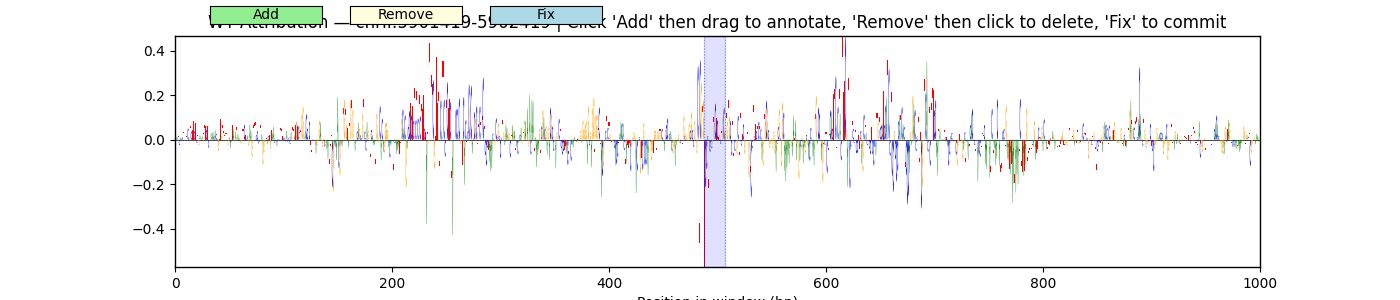

Click 'Add' → drag to annotate | 'Remove' → click red region | 'Fix' → commit annotations


In [4]:
%matplotlib widget
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.widgets import SpanSelector, Button
import pandas as pd
import logomaker

# --- Compute attribution for the WT sequence ---
attr_wt = model.compute_input_gradients(
    sequence=seq_wt, organism_index=org,
    head_name=HEAD_NAME, gradients_x_input=True,
)
attr_wt = jnp.float32(attr_wt)
attr_wt = attr_wt - jnp.mean(attr_wt, axis=-1, keepdims=True)
wt_attr_masked = np.array((attr_wt * seq_wt)[0])  # (1000, 4)

logo_df = pd.DataFrame(wt_attr_masked, columns=["A", "C", "G", "T"])

# --- State for custom annotations (separate from FIMO hits) ---
custom_motifs = []       # list of {"win_start": int, "win_end": int}
_custom_patches = []     # matplotlib patches for custom annotations
_mode = {"current": None}  # "add" or "remove" or None
_span_selector = {"obj": None}

# --- Plot attribution logo with FIMO hits overlaid ---
fig, ax_logo = plt.subplots(figsize=(14, 3))
logomaker.Logo(logo_df, ax=ax_logo, color_scheme="classic", show_spines=True, baseline_width=0.5)
ax_logo.set_xlim(0, WINDOW_SIZE)
ax_logo.set_xlabel("Position in window (bp)")
ax_logo.set_title(f"WT Attribution — {chrom}:{ws}-{we} | Click 'Add' then drag to annotate, 'Remove' then click to delete, 'Fix' to commit")

# Draw FIMO hits in blue (read-only reference)
for m in motifs_in_window:
    ax_logo.axvspan(m["win_start"], m["win_end"], color="blue", alpha=0.12, zorder=0)
    ax_logo.axvline(m["win_start"], color="blue", lw=0.8, ls=":", alpha=0.4)
    ax_logo.axvline(m["win_end"], color="blue", lw=0.8, ls=":", alpha=0.4)

# --- Helper: redraw custom patches ---
def _redraw_custom():
    for p in _custom_patches:
        p.remove()
    _custom_patches.clear()
    for cm in custom_motifs:
        patch = ax_logo.axvspan(cm["win_start"], cm["win_end"], color="red", alpha=0.20, zorder=1)
        _custom_patches.append(patch)
        for x in [cm["win_start"], cm["win_end"]]:
            line = ax_logo.axvline(x, color="red", lw=1, ls="--", alpha=0.6)
            _custom_patches.append(line)
    fig.canvas.draw_idle()

# --- Callbacks ---
def _on_span_select(xmin, xmax):
    """Called when user drags a span in Add mode."""
    s, e = int(round(xmin)), int(round(xmax))
    s, e = max(0, s), min(WINDOW_SIZE, e)
    if e - s < 2:
        return
    custom_motifs.append({"win_start": s, "win_end": e})
    _redraw_custom()
    print(f"  Added custom motif: {s}-{e} ({e-s}bp) seq={seq_str[s:e]}")

def _on_click(event):
    """In Remove mode, click on a custom annotation to delete it."""
    if _mode["current"] != "remove" or event.inaxes != ax_logo:
        return
    x = event.xdata
    # Find the custom motif that contains this x position
    for i, cm in enumerate(custom_motifs):
        if cm["win_start"] <= x <= cm["win_end"]:
            removed = custom_motifs.pop(i)
            _redraw_custom()
            print(f"  Removed custom motif: {removed['win_start']}-{removed['win_end']}")
            return
    print(f"  No custom motif at position {x:.0f} (FIMO hits are not removable)")

def _btn_add(event):
    _mode["current"] = "add"
    if _span_selector["obj"] is not None:
        _span_selector["obj"].set_active(True)
    print("Mode: ADD — click and drag on the plot to define a motif region")

def _btn_remove(event):
    _mode["current"] = "remove"
    if _span_selector["obj"] is not None:
        _span_selector["obj"].set_active(False)
    print("Mode: REMOVE — click on a red region to remove it")

def _btn_fix(event):
    _mode["current"] = None
    if _span_selector["obj"] is not None:
        _span_selector["obj"].set_active(False)
    # Build final annotation table
    all_annotations = []
    for i, m in enumerate(motifs_in_window):
        all_annotations.append({
            "idx": len(all_annotations), "win_start": m["win_start"], "win_end": m["win_end"],
            "source": "FIMO", "score": m["score"], "strand": m["strand"], "motif_seq": m["motif_seq"],
        })
    for cm in custom_motifs:
        all_annotations.append({
            "idx": len(all_annotations), "win_start": cm["win_start"], "win_end": cm["win_end"],
            "source": "custom", "score": None, "strand": ".", "motif_seq": seq_str[cm["win_start"]:cm["win_end"]],
        })
    all_annotations.sort(key=lambda x: x["win_start"])
    # Re-index after sort
    for i, a in enumerate(all_annotations):
        a["idx"] = i

    print(f"\n=== Fixed Annotations ({len(all_annotations)} total) ===")
    print(f"{'Idx':>3}  {'Start':>5}  {'End':>5}  {'Len':>3}  {'Source':>6}  {'Score':>6}  {'Strand':>6}  Sequence")
    print("-" * 75)
    for a in all_annotations:
        score_str = f"{a['score']:.1f}" if a["score"] is not None else "  —"
        print(f"{a['idx']:>3}  {a['win_start']:>5}  {a['win_end']:>5}  {a['win_end']-a['win_start']:>3}  "
              f"{a['source']:>6}  {score_str:>6}  {a['strand']:>6}  {a['motif_seq']}")

# --- Create buttons ---
ax_add = fig.add_axes([0.15, 0.92, 0.08, 0.06])
ax_rem = fig.add_axes([0.25, 0.92, 0.08, 0.06])
ax_fix = fig.add_axes([0.35, 0.92, 0.08, 0.06])
btn_add = Button(ax_add, "Add", color="lightgreen", hovercolor="green")
btn_rem = Button(ax_rem, "Remove", color="lightyellow", hovercolor="orange")
btn_fix = Button(ax_fix, "Fix", color="lightblue", hovercolor="dodgerblue")
btn_add.on_clicked(_btn_add)
btn_rem.on_clicked(_btn_remove)
btn_fix.on_clicked(_btn_fix)

# --- SpanSelector for Add mode ---
_span_selector["obj"] = SpanSelector(
    ax_logo, _on_span_select, "horizontal",
    useblit=True, props=dict(alpha=0.3, facecolor="red"),
    interactive=True, drag_from_anywhere=True,
)
_span_selector["obj"].set_active(False)  # start inactive

# --- Click handler for Remove mode ---
fig.canvas.mpl_connect("button_press_event", _on_click)

fig.subplots_adjust(top=0.88)
plt.show()
print("Click 'Add' → drag to annotate | 'Remove' → click red region | 'Fix' → commit annotations")

In [5]:
# ---- Configure & run virtual KO ----

# Build merged annotation list (FIMO + custom), sorted left-to-right
all_annotations = []
for m in motifs_in_window:
    all_annotations.append({"win_start": m["win_start"], "win_end": m["win_end"], "source": "FIMO"})
for cm in custom_motifs:
    all_annotations.append({"win_start": cm["win_start"], "win_end": cm["win_end"], "source": "custom"})
all_annotations.sort(key=lambda x: x["win_start"])

print(f"All annotations ({len(all_annotations)}):")
for i, a in enumerate(all_annotations):
    print(f"  {i}: {a['win_start']}-{a['win_end']} ({a['win_end']-a['win_start']}bp) [{a['source']}] seq={seq_str[a['win_start']:a['win_end']]}")

# --- Select which annotations to KO ---
motif_ko = [1, 2, 4,5,6,7,8,10,12]           # indices into all_annotations (edit this)
N_REPLICATES = 100

# Validate
if not motif_ko:
    raise ValueError("No motifs selected for KO! Set motif_ko above.")
for idx in motif_ko:
    if idx < 0 or idx >= len(all_annotations):
        raise ValueError(f"motif_ko index {idx} out of range — only {len(all_annotations)} annotations (0-{len(all_annotations)-1}).")

# Get WT sequence as numpy for shuffling
seq_wt_np = np.array(seq_wt[0])  # (1000, 4)

# 1. Generate N full-sequence dinucleotide shuffles
shuffled = dinucleotide_shuffle(seq_wt_np, n=N_REPLICATES, rng=np.random.default_rng(42))
print(f"\nGenerated {N_REPLICATES} dinucleotide shuffles: {shuffled.shape}")

# 2. Build mutant sequences: WT with KO'd regions replaced by shuffled bases
ko_regions = [(all_annotations[i]["win_start"], all_annotations[i]["win_end"]) for i in motif_ko]
print(f"KO annotation indices: {motif_ko}")
print(f"KO regions (window-relative): {ko_regions}")
for i, (s, e) in zip(motif_ko, ko_regions):
    print(f"  Annotation {i}: pos {s}-{e} ({e-s}bp) seq={seq_str[s:e]}")

mutants = np.tile(seq_wt_np, (N_REPLICATES, 1, 1))  # (N, 1000, 4)
for i in range(N_REPLICATES):
    for start, end in ko_regions:
        mutants[i, start:end, :] = shuffled[i, start:end, :]

# 3. Predict WT
pred_wt = get_scalar_prediction(model, seq_wt, org)
print(f"\nWT prediction: {pred_wt:.4f}")

# 4. Predict each mutant replicate
preds_mut = []
for i in range(N_REPLICATES):
    mut_jax = jnp.array(mutants[i:i+1])  # (1, 1000, 4)
    pred = get_scalar_prediction(model, mut_jax, org)
    preds_mut.append(pred)
preds_mut = np.array(preds_mut)

mean_mut = preds_mut.mean()
std_mut = preds_mut.std()
delta = mean_mut - pred_wt

print(f"Mut predictions: mean={mean_mut:.4f} +/- {std_mut:.4f}")
print(f"Delta (Mut - WT): {delta:.4f} +/- {std_mut:.4f}")
print(f"Individual replicate predictions: {preds_mut.round(4)}")

All annotations (13):
  0: 125-160 (35bp) [custom] seq=TTCCTAGAGACGGCGAATTTCGAAAACGAATGTGT
  1: 207-288 (81bp) [custom] seq=TTGCACGACCTCTCTCTCTCTTTCTATGTTTCGTTTTTCATCCTCTTCTACTCCGCGCTCACTCCGCACCGCTTCTTCTCC
  2: 315-358 (43bp) [custom] seq=ACTCAGTGAGAGACAATAAAAGTCGACGAGACGCCGAGTCTCC
  3: 402-441 (39bp) [custom] seq=TGGCACCTAACACTATTTCGGGGACGCGTCGCCAAGCGG
  4: 488-507 (19bp) [FIMO] seq=TCCCTCCGTGCTCTGCTGC
  5: 527-550 (23bp) [custom] seq=CTGTCCTCTCTCTCAGTGCGCGG
  6: 587-595 (8bp) [custom] seq=GAATGACC
  7: 604-623 (19bp) [custom] seq=CACTTCTCTACTTTCGAtc
  8: 639-663 (24bp) [custom] seq=tcctcccatgtccatccatcctcc
  9: 666-687 (21bp) [custom] seq=ccatcactccCAGAGACCCTT
  10: 691-705 (14bp) [custom] seq=TCACTCTTTCCAAT
  11: 759-794 (35bp) [custom] seq=TATTCCTGAATATAATAAATCTTATAGTTTTTAGA
  12: 876-897 (21bp) [custom] seq=TATTGATGCTTCACACCTGGG

Generated 100 dinucleotide shuffles: (100, 1000, 4)
KO annotation indices: [1, 2, 4, 5, 6, 7, 8, 10, 12]
KO regions (window-relative): [(207, 288), (315,

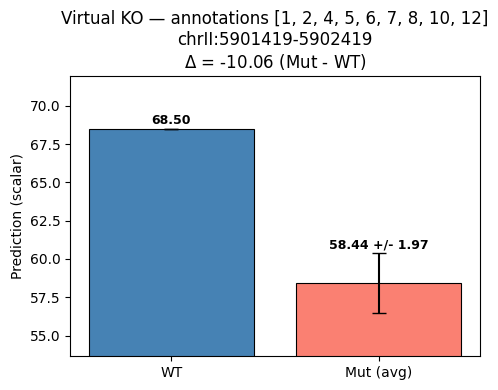

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt

# ---- Bar plot: WT vs Mut (average) ----
ko_labels = ", ".join(str(i) for i in motif_ko)

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(
    ["WT", "Mut (avg)"],
    [pred_wt, mean_mut],
    yerr=[0, std_mut],
    capsize=5,
    color=["steelblue", "salmon"],
    edgecolor="black",
    linewidth=0.8,
)

# Annotate bar values
ax.text(0, pred_wt + 0.3, f"{pred_wt:.2f}", ha="center", fontsize=9, fontweight="bold")
ax.text(1, mean_mut + std_mut + 0.3, f"{mean_mut:.2f} +/- {std_mut:.2f}", ha="center", fontsize=9, fontweight="bold")

# Zoom y-axis to make the difference visible
y_min = min(pred_wt, mean_mut - std_mut) * 0.95
y_max = max(pred_wt, mean_mut + std_mut) * 1.05
ax.set_ylim(y_min, y_max)

ax.set_ylabel("Prediction (scalar)")
ax.set_title(f"Virtual KO — annotations [{ko_labels}]\n{chrom}:{ws}-{we}\n$\\Delta$ = {delta:.2f} (Mut - WT)")

plt.tight_layout()
# fig.savefig("virtual_ko_barplot.png", dpi=150, bbox_inches="tight")
plt.show()

/tmp/slurm_tmp/834748/ipykernel_2465809/3658235235.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


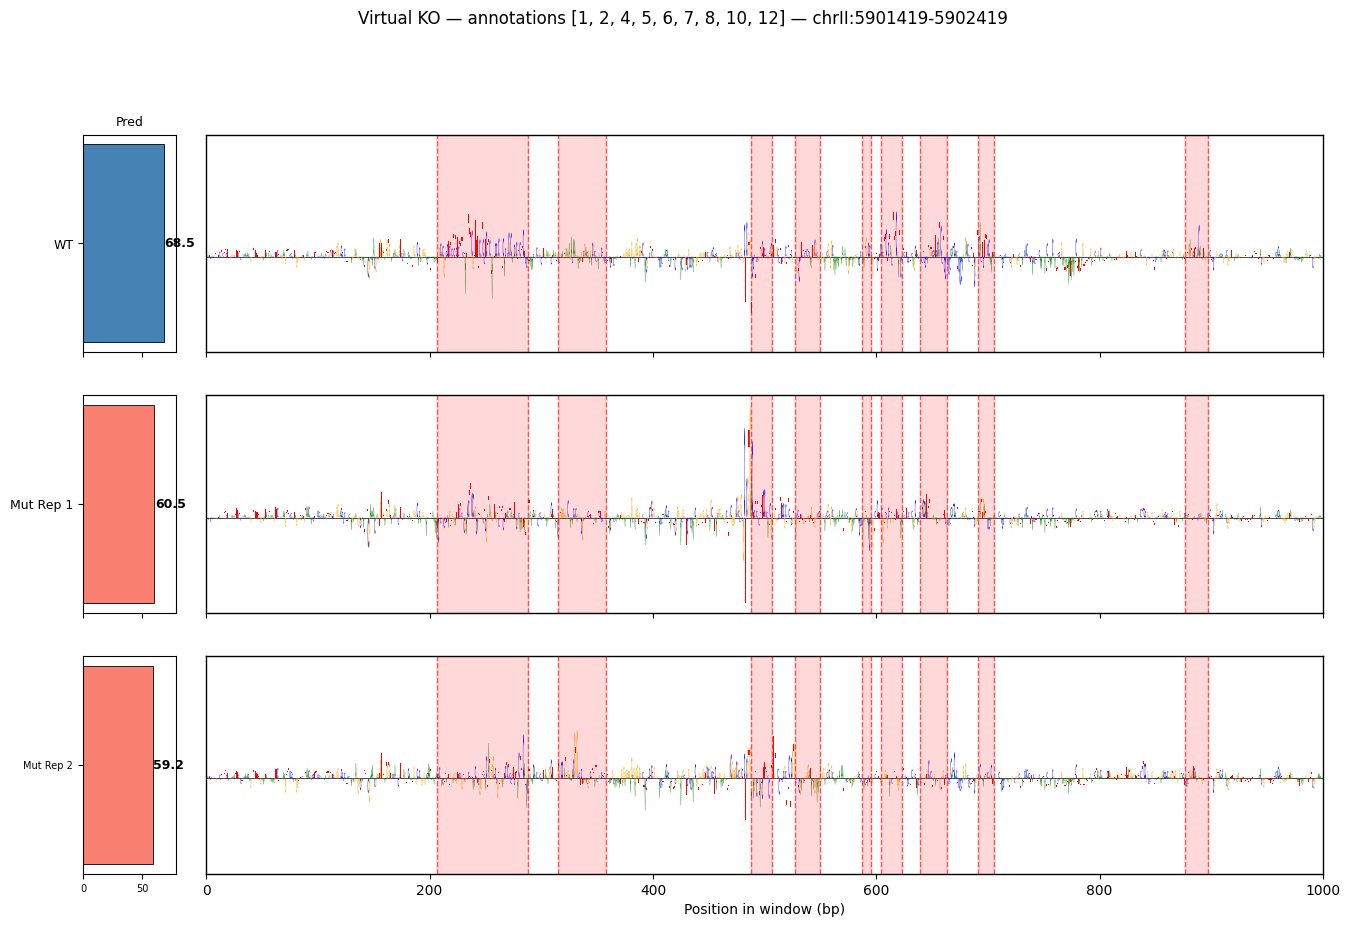

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import logomaker

# ---- Attribution maps: WT, Mut Rep 1, Mut Rep 2 with predictions ----
sequences = {
    "WT": (seq_wt, pred_wt),
    "Mut Rep 1": (jnp.array(mutants[0:1]), preds_mut[0]),
    "Mut Rep 2": (jnp.array(mutants[1:2]), preds_mut[1]),
}

ko_labels = ", ".join(str(i) for i in motif_ko)
n_rows = len(sequences)

# --- First pass: compute all attributions and find global y range ---
attr_data = {}
global_ymin, global_ymax = 0, 0
for label, (seq_input, pred_val) in sequences.items():
    attr = model.compute_input_gradients(
        sequence=seq_input, organism_index=org,
        head_name=HEAD_NAME, gradients_x_input=True,
    )
    attr = jnp.float32(attr)
    attr = attr - jnp.mean(attr, axis=-1, keepdims=True)
    wt_attr = np.array((attr * seq_input)[0])  # (1000, 4)
    attr_data[label] = wt_attr
    global_ymin = min(global_ymin, wt_attr.min())
    global_ymax = max(global_ymax, wt_attr.max())

# Add a small margin
y_margin = (global_ymax - global_ymin) * 0.05
global_ymin -= y_margin
global_ymax += y_margin

# --- Second pass: plot with shared scale ---
fig = plt.figure(figsize=(16, 3.2 * n_rows))
gs = gridspec.GridSpec(n_rows, 2, width_ratios=[1, 12], wspace=0.05)

for row, (label, (seq_input, pred_val)) in enumerate(sequences.items()):
    # --- Left: prediction bar ---
    ax_bar = fig.add_subplot(gs[row, 0])
    color = "steelblue" if label == "WT" else "salmon"
    ax_bar.barh([0], [pred_val], color=color, edgecolor="black", linewidth=0.6, height=0.6)
    ax_bar.set_xlim(0, max(pred_wt, preds_mut.max()) * 1.15)
    ax_bar.set_yticks([0])
    ax_bar.set_yticklabels([label], fontsize=9)
    ax_bar.text(pred_val + 0.3, 0, f"{pred_val:.1f}", va="center", fontsize=9, fontweight="bold")
    if row == 0:
        ax_bar.set_title("Pred", fontsize=9)
    if row < n_rows - 1:
        ax_bar.set_xticklabels([])
    else:
        ax_bar.tick_params(labelsize=7)

    # --- Right: attribution seq logo (normalized y-axis) ---
    ax_logo = fig.add_subplot(gs[row, 1])
    logo_df = pd.DataFrame(attr_data[label], columns=["A", "C", "G", "T"])
    logomaker.Logo(logo_df, ax=ax_logo, color_scheme="classic", show_spines=True, baseline_width=0.5)
    ax_logo.set_xlim(0, WINDOW_SIZE)
    ax_logo.set_ylim(global_ymin, global_ymax)
    ax_logo.set_yticks([])

    # Highlight KO regions in red
    for start, end in ko_regions:
        ax_logo.axvspan(start, end, color="red", alpha=0.15)
        ax_logo.axvline(start, color="red", lw=1, ls="--", alpha=0.6)
        ax_logo.axvline(end, color="red", lw=1, ls="--", alpha=0.6)

    if row < n_rows - 1:
        ax_logo.set_xticklabels([])
    else:
        ax_logo.set_xlabel("Position in window (bp)")

plt.suptitle(f"Virtual KO — annotations [{ko_labels}] — {chrom}:{ws}-{we}", fontsize=12, y=1.01)
plt.tight_layout()
# fig.savefig("virtual_ko_attributions.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# ---- Greedy SNP search within KO motif regions (3 runs x 10 iters) ----
N_ITER = 3
N_RUNS = 10

bases = [0, 1, 2, 3]  # A, C, G, T
base_names = {0: "A", 1: "C", 2: "G", 3: "T"}

# Positions eligible for mutation: union of all KO motif regions
eligible_positions = set()
for idx in motif_ko:
    s, e = all_annotations[idx]["win_start"], all_annotations[idx]["win_end"]
    eligible_positions.update(range(s, e))
eligible_positions = sorted(eligible_positions)
print(f"Eligible positions for SNPs: {len(eligible_positions)} bp across {len(motif_ko)} KO regions")

pred_wt = get_scalar_prediction(model, seq_wt, org)

# Store results for all runs
all_runs = []  # list of dicts: {history, seq_step1, seq_final, final_pred}

for run in range(N_RUNS):
    rng = np.random.default_rng(run)
    current_seq_np = np.array(seq_wt[0]).copy()

    # Apply a random initial SNP to break ties differently each run
    if run > 0:
        init_pos = rng.choice(eligible_positions)
        cur_base = int(np.argmax(current_seq_np[init_pos]))
        new_base = rng.choice([b for b in bases if b != cur_base])
        current_seq_np[init_pos, :] = 0.0
        current_seq_np[init_pos, new_base] = 1.0

    current_pred = get_scalar_prediction(model, jnp.array(current_seq_np[None, :, :]), org)
    history = [{"iter": 0, "pred": current_pred}]
    seq_step1 = None

    print(f"\n--- Run {run + 1}/{N_RUNS} ---")
    print(f"Iter  0: pred={current_pred:.4f}" + (f"  (init SNP pos={init_pos} {base_names[cur_base]}>{base_names[new_base]})" if run > 0 else " (WT)"))

    for iteration in range(1, N_ITER + 1):
        best_pred = -np.inf
        best_pos = None
        best_base = None

        for pos in eligible_positions:
            current_base = int(np.argmax(current_seq_np[pos]))
            for new_base in bases:
                if new_base == current_base:
                    continue
                candidate = current_seq_np.copy()
                candidate[pos, :] = 0.0
                candidate[pos, new_base] = 1.0
                pred = get_scalar_prediction(model, jnp.array(candidate[None, :, :]), org)
                if pred > best_pred:
                    best_pred = pred
                    best_pos = pos
                    best_base = new_base

        old_base = int(np.argmax(current_seq_np[best_pos]))
        current_seq_np[best_pos, :] = 0.0
        current_seq_np[best_pos, best_base] = 1.0
        current_pred = best_pred

        history.append({"iter": iteration, "pred": current_pred,
                        "pos": best_pos, "from": base_names[old_base], "to": base_names[best_base]})
        print(f"Iter {iteration:>2}: pred={current_pred:.4f}  SNP pos={best_pos} {base_names[old_base]}>{base_names[best_base]}")

        if iteration == 1:
            seq_step1 = current_seq_np.copy()

    all_runs.append({
        "history": history,
        "seq_step1": seq_step1,
        "seq_final": current_seq_np.copy(),
        "final_pred": current_pred,
    })

# Identify winning run
best_run_idx = int(np.argmax([r["final_pred"] for r in all_runs]))
print(f"\nBest run: {best_run_idx + 1} (final pred={all_runs[best_run_idx]['final_pred']:.4f})")
for i, r in enumerate(all_runs):
    marker = " <-- BEST" if i == best_run_idx else ""
    print(f"  Run {i+1}: final pred={r['final_pred']:.4f}{marker}")

Eligible positions for SNPs: 252 bp across 9 KO regions

--- Run 1/10 ---
Iter  0: pred=68.5000 (WT)
Iter  1: pred=70.0000  SNP pos=488 T>A
Iter  2: pred=71.5000  SNP pos=213 G>T
Iter  3: pred=72.5000  SNP pos=232 A>C

--- Run 2/10 ---
Iter  0: pred=68.5000  (init SNP pos=353 T>C)
Iter  1: pred=70.0000  SNP pos=488 T>A
Iter  2: pred=71.5000  SNP pos=213 G>T
Iter  3: pred=72.5000  SNP pos=232 A>C

--- Run 3/10 ---
Iter  0: pred=68.0000  (init SNP pos=657 T>A)
Iter  1: pred=69.5000  SNP pos=488 T>A
Iter  2: pred=71.0000  SNP pos=213 G>T
Iter  3: pred=72.0000  SNP pos=232 A>C

--- Run 4/10 ---
Iter  0: pred=68.0000  (init SNP pos=650 C>A)
Iter  1: pred=70.0000  SNP pos=488 T>A
Iter  2: pred=71.0000  SNP pos=213 G>T
Iter  3: pred=72.0000  SNP pos=208 T>G

--- Run 5/10 ---
Iter  0: pred=68.0000  (init SNP pos=613 A>T)
Iter  1: pred=70.0000  SNP pos=488 T>A
Iter  2: pred=71.0000  SNP pos=213 G>T
Iter  3: pred=72.5000  SNP pos=232 A>T

--- Run 6/10 ---
Iter  0: pred=68.0000  (init SNP pos=590

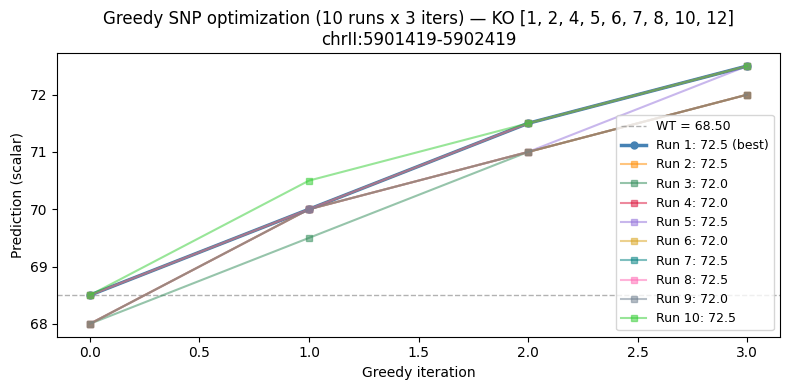

/tmp/slurm_tmp/834748/ipykernel_2465809/2105814347.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


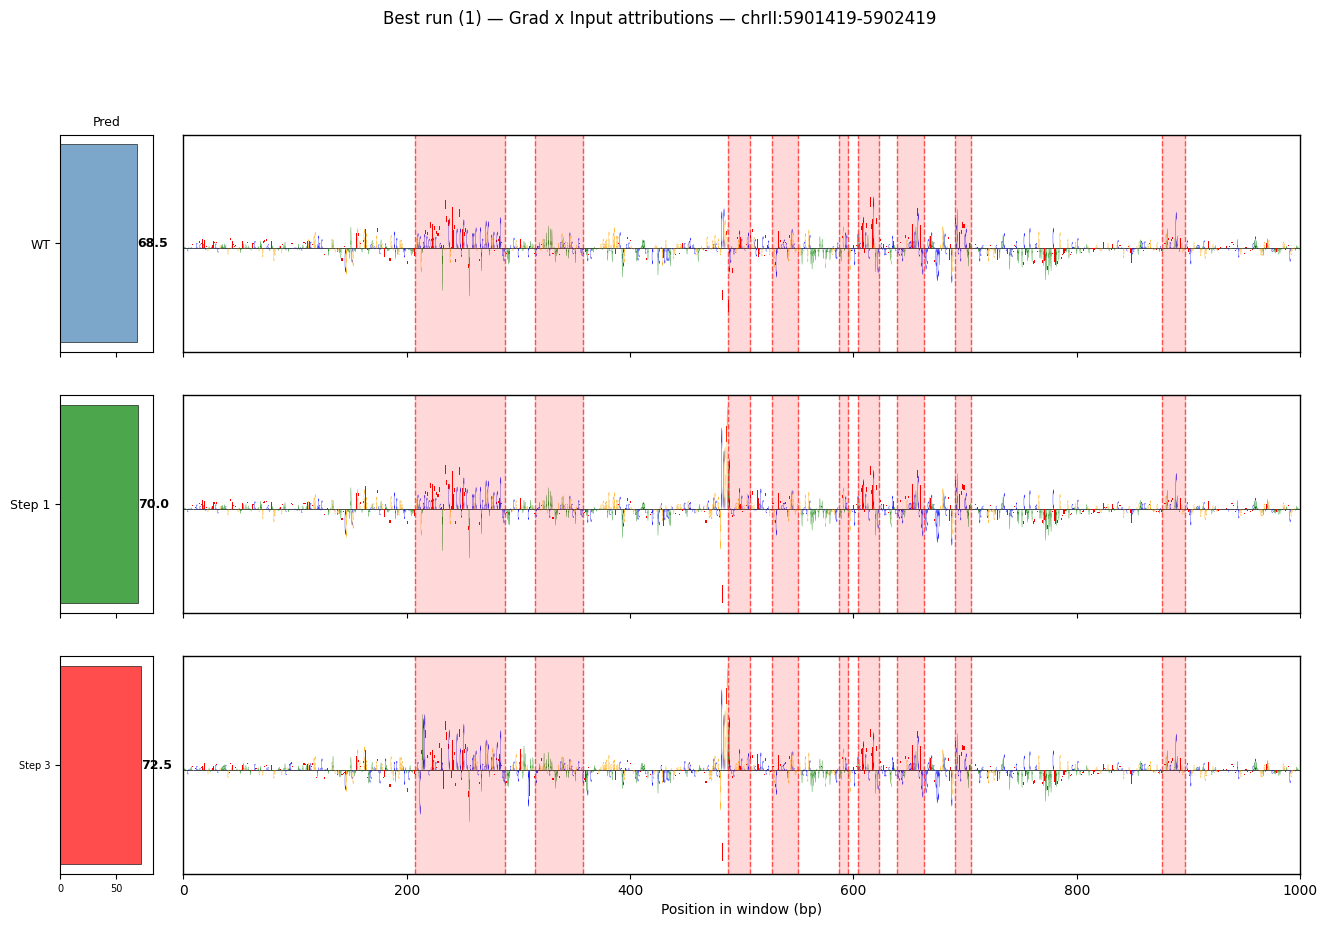

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import logomaker

# ---- Greedy search results: 3 runs on one line plot, logos for best run ----

run_colors = ["steelblue", "darkorange", "seagreen", "crimson", "mediumpurple", "goldenrod", "teal", "hotpink", "slategray", "limegreen"]

# --- Line plot: all 3 runs ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.axhline(pred_wt, color="gray", ls="--", lw=1, alpha=0.6, label=f"WT = {pred_wt:.2f}")

for i, r in enumerate(all_runs):
    iters = [h["iter"] for h in r["history"]]
    preds = [h["pred"] for h in r["history"]]
    is_best = (i == best_run_idx)
    lw = 2.5 if is_best else 1.5
    alpha = 1.0 if is_best else 0.5
    marker = "o" if is_best else "s"
    label = f"Run {i+1}: {preds[-1]:.1f}" + (" (best)" if is_best else "")
    ax.plot(iters, preds, f"{marker}-", color=run_colors[i], markersize=5, linewidth=lw, alpha=alpha, label=label)

ax.set_xlabel("Greedy iteration")
ax.set_ylabel("Prediction (scalar)")
ko_labels = ", ".join(str(i) for i in motif_ko)
ax.set_title(f"Greedy SNP optimization ({N_RUNS} runs x {N_ITER} iters) — KO [{ko_labels}]\n{chrom}:{ws}-{we}")
ax.legend(fontsize=9)
plt.tight_layout()
# fig.savefig("greedy_snp_lineplot.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Attribution logos: WT, Step 1, Final step of BEST run only ---
best = all_runs[best_run_idx]
best_preds = [h["pred"] for h in best["history"]]

greedy_sequences = {
    f"WT (pred={pred_wt:.1f})": jnp.array(np.array(seq_wt[0])[None, :, :]),
    f"Step 1 (pred={best_preds[0]:.1f})": jnp.array(best["seq_step1"][None, :, :]),
    f"Step {N_ITER} (pred={best_preds[-1]:.1f})": jnp.array(best["seq_final"][None, :, :]),
}

n_rows = len(greedy_sequences)

# First pass: compute attributions and find global y range
greedy_attr_data = {}
g_ymin, g_ymax = 0, 0
for label, seq_input in greedy_sequences.items():
    attr = model.compute_input_gradients(
        sequence=seq_input, organism_index=org,
        head_name=HEAD_NAME, gradients_x_input=True,
    )
    attr = jnp.float32(attr)
    attr = attr - jnp.mean(attr, axis=-1, keepdims=True)
    masked = np.array((attr * seq_input)[0])
    greedy_attr_data[label] = masked
    g_ymin = min(g_ymin, masked.min())
    g_ymax = max(g_ymax, masked.max())

y_margin = (g_ymax - g_ymin) * 0.05
g_ymin -= y_margin
g_ymax += y_margin

# Second pass: plot with prediction bars
fig = plt.figure(figsize=(16, 3.2 * n_rows))
gs = gridspec.GridSpec(n_rows, 2, width_ratios=[1, 12], wspace=0.05)

pred_values = [pred_wt, best_preds[1], best_preds[-1]]
pred_max = max(pred_values) * 1.15

for row, (label, seq_input) in enumerate(greedy_sequences.items()):
    # --- Left: prediction bar ---
    ax_bar = fig.add_subplot(gs[row, 0])
    color = "steelblue" if row == 0 else ("green" if row == 1 else "red")
    ax_bar.barh([0], [pred_values[row]], color=color, edgecolor="black", linewidth=0.6, height=0.6, alpha=0.7)
    ax_bar.set_xlim(0, pred_max)
    ax_bar.set_yticks([0])
    ax_bar.set_yticklabels([label.split(" (")[0]], fontsize=9)
    ax_bar.text(pred_values[row] + 0.3, 0, f"{pred_values[row]:.1f}", va="center", fontsize=9, fontweight="bold")
    if row == 0:
        ax_bar.set_title("Pred", fontsize=9)
    if row < n_rows - 1:
        ax_bar.set_xticklabels([])
    else:
        ax_bar.tick_params(labelsize=7)

    # --- Right: attribution seq logo (normalized y-axis) ---
    ax_logo = fig.add_subplot(gs[row, 1])
    logo_df = pd.DataFrame(greedy_attr_data[label], columns=["A", "C", "G", "T"])
    logomaker.Logo(logo_df, ax=ax_logo, color_scheme="classic", show_spines=True, baseline_width=0.5)
    ax_logo.set_xlim(0, WINDOW_SIZE)
    ax_logo.set_ylim(g_ymin, g_ymax)
    ax_logo.set_yticks([])

    # Highlight KO regions
    for idx in motif_ko:
        s, e = all_annotations[idx]["win_start"], all_annotations[idx]["win_end"]
        ax_logo.axvspan(s, e, color="red", alpha=0.15)
        ax_logo.axvline(s, color="red", lw=1, ls="--", alpha=0.6)
        ax_logo.axvline(e, color="red", lw=1, ls="--", alpha=0.6)

    if row < n_rows - 1:
        ax_logo.set_xticklabels([])
    else:
        ax_logo.set_xlabel("Position in window (bp)")

plt.suptitle(f"Best run ({best_run_idx + 1}) — Grad x Input attributions — {chrom}:{ws}-{we}", fontsize=12, y=1.01)
plt.tight_layout()
# fig.savefig("greedy_snp_attributions.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# ---- Greedy SNP search — MINIMIZE prediction (3 runs x 10 iters) ----
N_ITER_DN = 10
N_RUNS_DN = 3

bases = [0, 1, 2, 3]
base_names = {0: "A", 1: "C", 2: "G", 3: "T"}

eligible_positions = set()
for idx in motif_ko:
    s, e = all_annotations[idx]["win_start"], all_annotations[idx]["win_end"]
    eligible_positions.update(range(s, e))
eligible_positions = sorted(eligible_positions)
print(f"Eligible positions for SNPs: {len(eligible_positions)} bp across {len(motif_ko)} KO regions")

pred_wt = get_scalar_prediction(model, seq_wt, org)

all_runs_dn = []

for run in range(N_RUNS_DN):
    rng = np.random.default_rng(run + 100)
    current_seq_np = np.array(seq_wt[0]).copy()

    if run > 0:
        init_pos = rng.choice(eligible_positions)
        cur_base = int(np.argmax(current_seq_np[init_pos]))
        new_base = rng.choice([b for b in bases if b != cur_base])
        current_seq_np[init_pos, :] = 0.0
        current_seq_np[init_pos, new_base] = 1.0

    current_pred = get_scalar_prediction(model, jnp.array(current_seq_np[None, :, :]), org)
    history = [{"iter": 0, "pred": current_pred}]
    seq_step1 = None

    print(f"\n--- Run {run + 1}/{N_RUNS_DN} (minimize) ---")
    print(f"Iter  0: pred={current_pred:.4f}" + (f"  (init SNP pos={init_pos} {base_names[cur_base]}>{base_names[new_base]})" if run > 0 else " (WT)"))

    for iteration in range(1, N_ITER_DN + 1):
        best_pred = np.inf  # minimize
        best_pos = None
        best_base = None

        for pos in eligible_positions:
            current_base = int(np.argmax(current_seq_np[pos]))
            for new_base in bases:
                if new_base == current_base:
                    continue
                candidate = current_seq_np.copy()
                candidate[pos, :] = 0.0
                candidate[pos, new_base] = 1.0
                pred = get_scalar_prediction(model, jnp.array(candidate[None, :, :]), org)
                if pred < best_pred:
                    best_pred = pred
                    best_pos = pos
                    best_base = new_base

        old_base = int(np.argmax(current_seq_np[best_pos]))
        current_seq_np[best_pos, :] = 0.0
        current_seq_np[best_pos, best_base] = 1.0
        current_pred = best_pred

        history.append({"iter": iteration, "pred": current_pred,
                        "pos": best_pos, "from": base_names[old_base], "to": base_names[best_base]})
        print(f"Iter {iteration:>2}: pred={current_pred:.4f}  SNP pos={best_pos} {base_names[old_base]}>{base_names[best_base]}")

        if iteration == 1:
            seq_step1 = current_seq_np.copy()

    all_runs_dn.append({
        "history": history,
        "seq_step1": seq_step1,
        "seq_final": current_seq_np.copy(),
        "final_pred": current_pred,
    })

best_run_dn_idx = int(np.argmin([r["final_pred"] for r in all_runs_dn]))
print(f"\nBest run (lowest): {best_run_dn_idx + 1} (final pred={all_runs_dn[best_run_dn_idx]['final_pred']:.4f})")
for i, r in enumerate(all_runs_dn):
    marker = " <-- BEST" if i == best_run_dn_idx else ""
    print(f"  Run {i+1}: final pred={r['final_pred']:.4f}{marker}")

Eligible positions for SNPs: 252 bp across 9 KO regions

--- Run 1/3 (minimize) ---
Iter  0: pred=68.5000 (WT)
Iter  1: pred=67.0000  SNP pos=506 C>G
Iter  2: pred=66.0000  SNP pos=213 G>A
Iter  3: pred=65.0000  SNP pos=211 A>G
Iter  4: pred=63.7500  SNP pos=617 T>A
Iter  5: pred=63.0000  SNP pos=235 T>A
Iter  6: pred=62.0000  SNP pos=247 T>A
Iter  7: pred=61.0000  SNP pos=545 C>G
Iter  8: pred=59.7500  SNP pos=534 C>A
Iter  9: pred=57.7500  SNP pos=532 C>T
Iter 10: pred=56.2500  SNP pos=594 C>A

--- Run 2/3 (minimize) ---
Iter  0: pred=68.5000  (init SNP pos=285 T>G)
Iter  1: pred=67.0000  SNP pos=506 C>G
Iter  2: pred=66.0000  SNP pos=213 G>A
Iter  3: pred=65.0000  SNP pos=211 A>G
Iter  4: pred=63.7500  SNP pos=247 T>G
Iter  5: pred=62.5000  SNP pos=545 C>G
Iter  6: pred=61.2500  SNP pos=534 C>A
Iter  7: pred=59.0000  SNP pos=532 C>T
Iter  8: pred=58.0000  SNP pos=495 G>C
Iter  9: pred=56.7500  SNP pos=235 T>A
Iter 10: pred=55.7500  SNP pos=263 G>C

--- Run 3/3 (minimize) ---
Iter  0

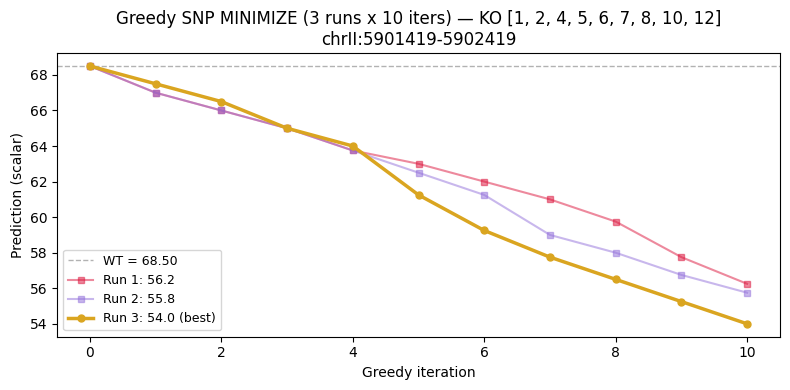

/tmp/slurm_tmp/834748/ipykernel_2465809/1158613854.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


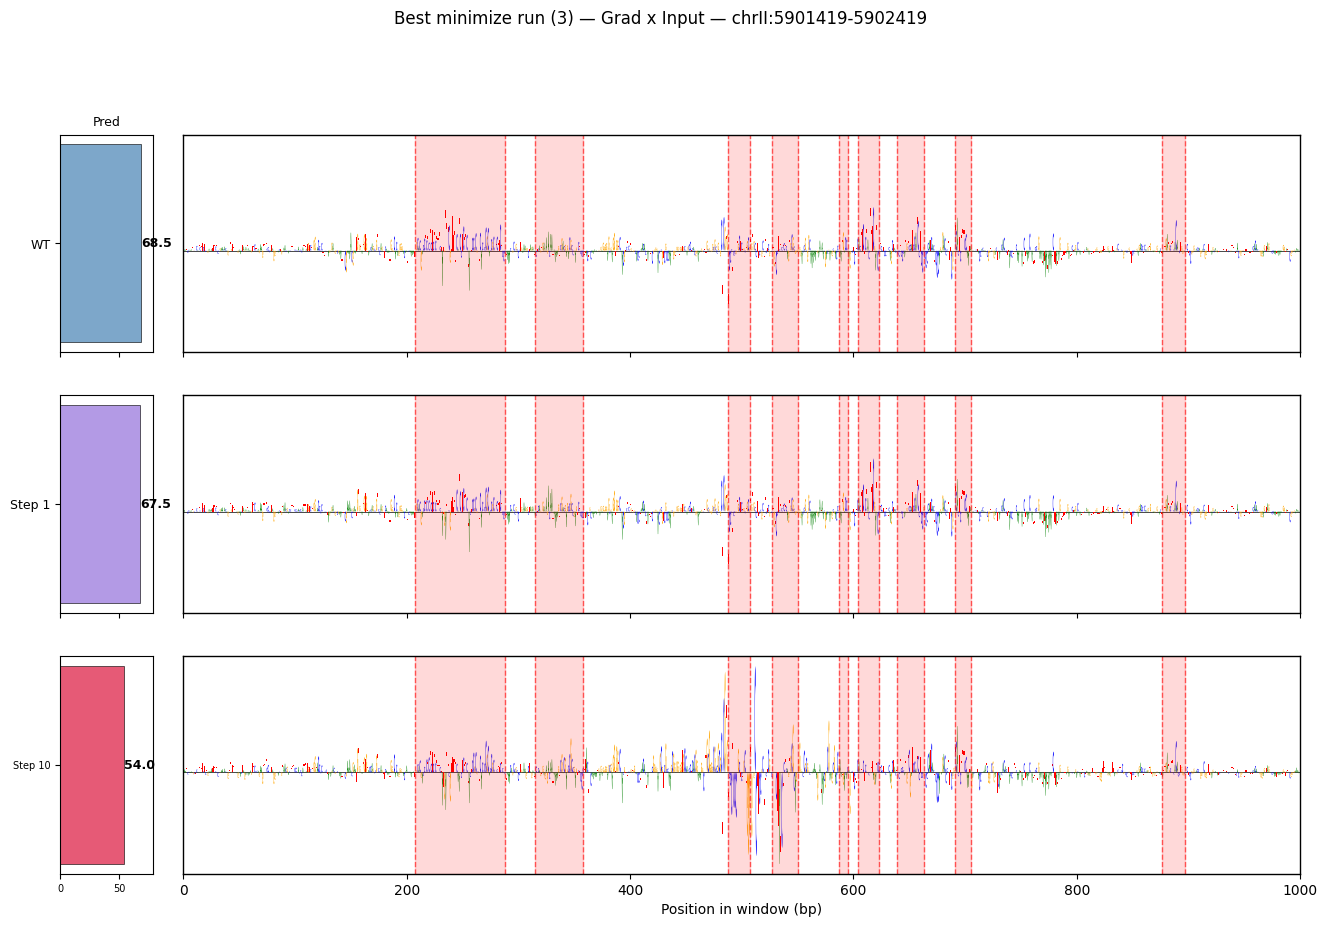

In [13]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import logomaker

# ---- Minimize greedy search results ----

run_colors_dn = ["crimson", "mediumpurple", "goldenrod"]

# --- Line plot: all 3 runs ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.axhline(pred_wt, color="gray", ls="--", lw=1, alpha=0.6, label=f"WT = {pred_wt:.2f}")

for i, r in enumerate(all_runs_dn):
    iters = [h["iter"] for h in r["history"]]
    preds = [h["pred"] for h in r["history"]]
    is_best = (i == best_run_dn_idx)
    lw = 2.5 if is_best else 1.5
    alpha = 1.0 if is_best else 0.5
    marker = "o" if is_best else "s"
    label = f"Run {i+1}: {preds[-1]:.1f}" + (" (best)" if is_best else "")
    ax.plot(iters, preds, f"{marker}-", color=run_colors_dn[i], markersize=5, linewidth=lw, alpha=alpha, label=label)

ax.set_xlabel("Greedy iteration")
ax.set_ylabel("Prediction (scalar)")
ko_labels = ", ".join(str(i) for i in motif_ko)
ax.set_title(f"Greedy SNP MINIMIZE ({N_RUNS_DN} runs x {N_ITER_DN} iters) — KO [{ko_labels}]\n{chrom}:{ws}-{we}")
ax.legend(fontsize=9)
plt.tight_layout()
# fig.savefig("greedy_snp_minimize_lineplot.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Attribution logos: WT, Step 1, Final step of BEST (lowest) run ---
best_dn = all_runs_dn[best_run_dn_idx]
best_dn_preds = [h["pred"] for h in best_dn["history"]]

greedy_dn_sequences = {
    f"WT (pred={pred_wt:.1f})": jnp.array(np.array(seq_wt[0])[None, :, :]),
    f"Step 1 (pred={best_dn_preds[1]:.1f})": jnp.array(best_dn["seq_step1"][None, :, :]),
    f"Step {N_ITER_DN} (pred={best_dn_preds[-1]:.1f})": jnp.array(best_dn["seq_final"][None, :, :]),
}

n_rows = len(greedy_dn_sequences)

greedy_dn_attr = {}
g_ymin, g_ymax = 0, 0
for label, seq_input in greedy_dn_sequences.items():
    attr = model.compute_input_gradients(
        sequence=seq_input, organism_index=org,
        head_name=HEAD_NAME, gradients_x_input=True,
    )
    attr = jnp.float32(attr)
    attr = attr - jnp.mean(attr, axis=-1, keepdims=True)
    masked = np.array((attr * seq_input)[0])
    greedy_dn_attr[label] = masked
    g_ymin = min(g_ymin, masked.min())
    g_ymax = max(g_ymax, masked.max())

y_margin = (g_ymax - g_ymin) * 0.05
g_ymin -= y_margin
g_ymax += y_margin

fig = plt.figure(figsize=(16, 3.2 * n_rows))
gs = gridspec.GridSpec(n_rows, 2, width_ratios=[1, 12], wspace=0.05)

pred_values = [pred_wt, best_dn_preds[1], best_dn_preds[-1]]
pred_max = max(pred_values) * 1.15

for row, (label, seq_input) in enumerate(greedy_dn_sequences.items()):
    ax_bar = fig.add_subplot(gs[row, 0])
    color = "steelblue" if row == 0 else ("mediumpurple" if row == 1 else "crimson")
    ax_bar.barh([0], [pred_values[row]], color=color, edgecolor="black", linewidth=0.6, height=0.6, alpha=0.7)
    ax_bar.set_xlim(0, pred_max)
    ax_bar.set_yticks([0])
    ax_bar.set_yticklabels([label.split(" (")[0]], fontsize=9)
    ax_bar.text(pred_values[row] + 0.3, 0, f"{pred_values[row]:.1f}", va="center", fontsize=9, fontweight="bold")
    if row == 0:
        ax_bar.set_title("Pred", fontsize=9)
    if row < n_rows - 1:
        ax_bar.set_xticklabels([])
    else:
        ax_bar.tick_params(labelsize=7)

    ax_logo = fig.add_subplot(gs[row, 1])
    logo_df = pd.DataFrame(greedy_dn_attr[label], columns=["A", "C", "G", "T"])
    logomaker.Logo(logo_df, ax=ax_logo, color_scheme="classic", show_spines=True, baseline_width=0.5)
    ax_logo.set_xlim(0, WINDOW_SIZE)
    ax_logo.set_ylim(g_ymin, g_ymax)
    ax_logo.set_yticks([])

    for idx in motif_ko:
        s, e = all_annotations[idx]["win_start"], all_annotations[idx]["win_end"]
        ax_logo.axvspan(s, e, color="red", alpha=0.15)
        ax_logo.axvline(s, color="red", lw=1, ls="--", alpha=0.6)
        ax_logo.axvline(e, color="red", lw=1, ls="--", alpha=0.6)

    if row < n_rows - 1:
        ax_logo.set_xticklabels([])
    else:
        ax_logo.set_xlabel("Position in window (bp)")

plt.suptitle(f"Best minimize run ({best_run_dn_idx + 1}) — Grad x Input — {chrom}:{ws}-{we}", fontsize=12, y=1.01)
plt.tight_layout()
# fig.savefig("greedy_snp_minimize_attributions.png", dpi=150, bbox_inches="tight")
plt.show()